# exp-gs-002-09 — LGBM 결측 노이즈 augmentation

## 목표

원본 유전자 G 입력에서 LightGBM 기준선과, fold-train에만 고정 결측 노이즈를 주입한 후보를 비교한다. 이 실험은 결측 입력 성능을 직접 재현하는 것이 아니라, 결측 노이즈를 포함한 학습이 **원본 validation OOF Macro F1**에 미치는 영향을 점검한다.

## 사전 고정 규칙 및 누수 방지

- 이 노트북은 학습 데이터만 읽으며 평가 데이터 파일·통계·결측 패턴을 참조하지 않는다.
- `MASK_RATE=0.001`, `MASK_SEED=42`, 대상은 fold-train의 전체 유전자 셀 균일 무작위 선택으로 고정한다.
- validation fold는 원본 상태로 평가한다.
- 모델·G 피처·CV split·평가 방식은 두 후보에서 동일하며, 마스킹 유무만 다르다.
- 마스킹 후보가 seed 42 OOF에서 기준선을 이길 때에만 42/2024/777 안정성 검증 후보로 넘긴다.
- 제출 파일은 만들지 않는다.


## LGBM 고정 파라미터

| 파라미터 | 값 |
|---|---:|
| objective / num_class | multiclass / train label 수 |
| n_estimators | 500 |
| learning_rate | 0.05 |
| num_leaves | 31 |
| min_child_samples | 20 |
| colsample_bytree / subsample / subsample_freq | 0.8 / 0.8 / 1 |
| reg_lambda / reg_alpha | 1.0 / 0.0 |
| class_weight | balanced |
| random_state | 42 |
| n_jobs | -1 |

위 값은 09 내부에서 비교 두 후보에 동일하게 적용한다. 09의 목적은 파라미터 탐색이 아니라 결측 노이즈 augmentation의 효과 분리다.


In [1]:
from __future__ import annotations

import json
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from tqdm.auto import tqdm

try:
    from lightgbm import LGBMClassifier
except ImportError as exc:
    raise ImportError(
        'LightGBM이 현재 커널에 없습니다. 이 노트북의 커널에서 `pip install lightgbm` 후 커널을 재시작하세요.'
    ) from exc

def find_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / 'data' / 'raw' / 'train.csv').exists():
            return candidate
    raise FileNotFoundError('프로젝트 루트를 찾지 못했습니다. data/raw/train.csv 경로를 확인하세요.')

ROOT = find_root()
DATA_DIR = ROOT / 'data' / 'raw'
RESULT_DIR = ROOT / 'experiments' / 'gs' / 'notebooks' / 'eda_pre_002' / 'result'
RESULT_DIR.mkdir(parents=True, exist_ok=True)

ID_COL = 'ID'
TARGET_COL = 'SUBCLASS'
N_SPLITS = 5
CV_SEED = 42
MASK_RATE = 0.001
MASK_SEED = 42
RUN_EXPERIMENT = True

# 평가 데이터 파일은 이 노트북에서 읽지 않는다.
EVALUATION_DATA_READ = False

LGBM_PARAMS = {
    'objective': 'multiclass',
    'n_estimators': 500,
    'learning_rate': 0.05,
    'num_leaves': 31,
    'min_child_samples': 20,
    'colsample_bytree': 0.8,
    'subsample': 0.8,
    'subsample_freq': 1,
    'reg_lambda': 1.0,
    'reg_alpha': 0.0,
    'class_weight': 'balanced',
    'random_state': 42,
    'n_jobs': -1,
    'verbosity': -1,
}

print({'root': ROOT, 'result_dir': RESULT_DIR, 'mask_rate': MASK_RATE, 'mask_seed': MASK_SEED, 'evaluation_data_read': EVALUATION_DATA_READ})


{'root': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton'), 'result_dir': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/eda_pre_002/result'), 'mask_rate': 0.001, 'mask_seed': 42, 'evaluation_data_read': False}


/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Train 로드 및 G 인코딩

관측된 `WT`는 0, 하나 이상의 변이 문자열은 1로 둔다. train 원본은 결측이 없어야 하며, 이 검증이 실패하면 실험을 중단한다.


In [2]:
train = pd.read_csv(DATA_DIR / 'train.csv')
genes = [column for column in train.columns if column not in (ID_COL, TARGET_COL)]
assert genes, '유전자 피처를 찾지 못했습니다.'
train_nan_count = int(train[genes].isna().sum().sum())
assert train_nan_count == 0, f'train 원본 결측이 발견되었습니다: {train_nan_count}'

def build_gene_matrix(frame: pd.DataFrame, columns: list[str]) -> np.ndarray:
    matrix = np.empty((len(frame), len(columns)), dtype=np.float32)
    for col_index, gene in enumerate(tqdm(columns, desc='G binary encoding', unit='gene')):
        # train은 결측 없음이 검증되었고, WT 이외의 문자열은 mutation event로 인코딩한다.
        matrix[:, col_index] = frame[gene].ne('WT').to_numpy(dtype=np.float32)
    return matrix

X = build_gene_matrix(train, genes)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(train[TARGET_COL])
class_names = label_encoder.classes_

assert not np.isnan(X).any(), '원본 train G 행렬에 결측이 있으면 안 됩니다.'
print({'train_rows': len(train), 'gene_count': len(genes), 'class_count': len(class_names), 'train_nan_count': train_nan_count, 'matrix_shape': X.shape})


G binary encoding: 100%|██████████| 4384/4384 [00:01<00:00, 2866.48gene/s]

{'train_rows': 6201, 'gene_count': 4384, 'class_count': 26, 'train_nan_count': 0, 'matrix_shape': (6201, 4384)}


## 2. Fold-train 전용 결측 노이즈 함수

마스킹 index는 `MASK_SEED + fold 번호`와 해당 fold의 train index만으로 결정한다. validation 행은 복사본에서도 변경하지 않는다.


In [3]:
def mask_fold_train(
    matrix: np.ndarray,
    train_index: np.ndarray,
    rate: float,
    seed: int,
    fold: int,
) -> tuple[np.ndarray, int]:
    if not 0 < rate < 1:
        raise ValueError('MASK_RATE는 0과 1 사이여야 합니다.')
    masked_train = matrix[train_index].copy()
    n_rows, n_genes = masked_train.shape
    mask_count = max(1, int(round(n_rows * n_genes * rate)))
    rng = np.random.default_rng(seed + fold)
    flat_index = rng.choice(n_rows * n_genes, size=mask_count, replace=False)
    masked_train[flat_index // n_genes, flat_index % n_genes] = np.nan
    return masked_train, mask_count

# 불변식 점검: validation을 변경하지 않으며, fold-train에만 결측을 만든다.
splitter_check = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=CV_SEED)
first_train_index, first_valid_index = next(splitter_check.split(X, y))
masked_check, masked_check_count = mask_fold_train(X, first_train_index, MASK_RATE, MASK_SEED, fold=0)
assert masked_check_count > 0
assert not np.isnan(X[first_valid_index]).any(), 'validation 원본에 결측이 있으면 안 됩니다.'
assert np.isnan(masked_check).sum() == masked_check_count
del masked_check
print({'first_fold_masked_train_cell_count': masked_check_count, 'validation_masked_cell_count': 0})


{'first_fold_masked_train_cell_count': 21745, 'validation_masked_cell_count': 0}


## 3. 동일 OOF 조건으로 기준선과 augmentation 비교

두 후보는 같은 fold·같은 LGBM 파라미터·같은 G 입력을 사용한다. 차이는 fold-train의 마스킹 적용 여부뿐이다.


In [4]:
def run_candidate(candidate: str, apply_mask: bool) -> tuple[dict, pd.DataFrame, pd.DataFrame]:
    splitter = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=CV_SEED)
    oof_probability = np.zeros((len(y), len(class_names)), dtype=np.float32)
    fold_rows: list[dict] = []
    started = perf_counter()

    for fold, (train_index, valid_index) in enumerate(
        tqdm(splitter.split(X, y), total=N_SPLITS, desc=f'{candidate} | 5-fold OOF', unit='fold'), start=1
    ):
        if apply_mask:
            X_train, masked_count = mask_fold_train(X, train_index, MASK_RATE, MASK_SEED, fold)
        else:
            X_train, masked_count = X[train_index], 0
        X_valid = X[valid_index]  # 원본 validation 유지
        assert not np.isnan(X_valid).any(), 'validation에 augmentation 결측이 들어가면 안 됩니다.'

        model = LGBMClassifier(num_class=len(class_names), **LGBM_PARAMS)
        model.fit(X_train, y[train_index])
        valid_probability = model.predict_proba(X_valid).astype(np.float32)
        oof_probability[valid_index] = valid_probability
        valid_prediction = valid_probability.argmax(axis=1)
        fold_rows.append({
            'candidate': candidate,
            'fold': fold,
            'fold_macro_f1': f1_score(y[valid_index], valid_prediction, average='macro'),
            'fold_accuracy': accuracy_score(y[valid_index], valid_prediction),
            'masked_train_cell_count': masked_count,
            'validation_masked_cell_count': 0,
        })

    oof_prediction = oof_probability.argmax(axis=1)
    report = classification_report(y, oof_prediction, target_names=class_names, output_dict=True, zero_division=0)
    class_f1 = pd.DataFrame([{
        'candidate': candidate,
        'class': class_name,
        'precision': report[class_name]['precision'],
        'recall': report[class_name]['recall'],
        'class_f1': report[class_name]['f1-score'],
        'support': report[class_name]['support'],
    } for class_name in class_names])
    fold_result = pd.DataFrame(fold_rows)
    summary = {
        'candidate': candidate,
        'model': 'lightgbm',
        'cv_seed': CV_SEED,
        'oof_macro_f1': f1_score(y, oof_prediction, average='macro'),
        'oof_accuracy': accuracy_score(y, oof_prediction),
        'fold_macro_f1_mean': fold_result['fold_macro_f1'].mean(),
        'fold_macro_f1_std': fold_result['fold_macro_f1'].std(ddof=0),
        'feature_count': len(genes),
        'masked_train_cell_count': int(fold_result['masked_train_cell_count'].sum()),
        'validation_masked_cell_count': 0,
        'runtime_seconds': perf_counter() - started,
    }
    oof_frame = pd.DataFrame({ID_COL: train[ID_COL], 'true_class': train[TARGET_COL], 'predicted_class': label_encoder.inverse_transform(oof_prediction)})
    return summary, fold_result, class_f1, oof_frame

if RUN_EXPERIMENT:
    runs = []
    for candidate, apply_mask in [('lgbm_native_baseline', False), ('lgbm_mask_noise_0p001', True)]:
        summary, fold_result, class_f1, oof_frame = run_candidate(candidate, apply_mask)
        runs.append((summary, fold_result, class_f1, oof_frame))
else:
    runs = []
    print('RUN_EXPERIMENT=False: 실행하지 않았습니다.')


lgbm_native_baseline | 5-fold OOF: 100%|██████████| 5/5 [09:31<00:00, 114.23s/fold]
lgbm_mask_noise_0p001 | 5-fold OOF: 100%|██████████| 5/5 [18:09<00:00, 217.83s/fold]


## 4. 결과 저장·감사 기록·시각화

결과는 기준선 대비 점수 변화, fold별 점수, 클래스별 F1, 마스킹 감사 정보와 함께 저장한다. 실행 후에만 결과 수치를 해석한다.


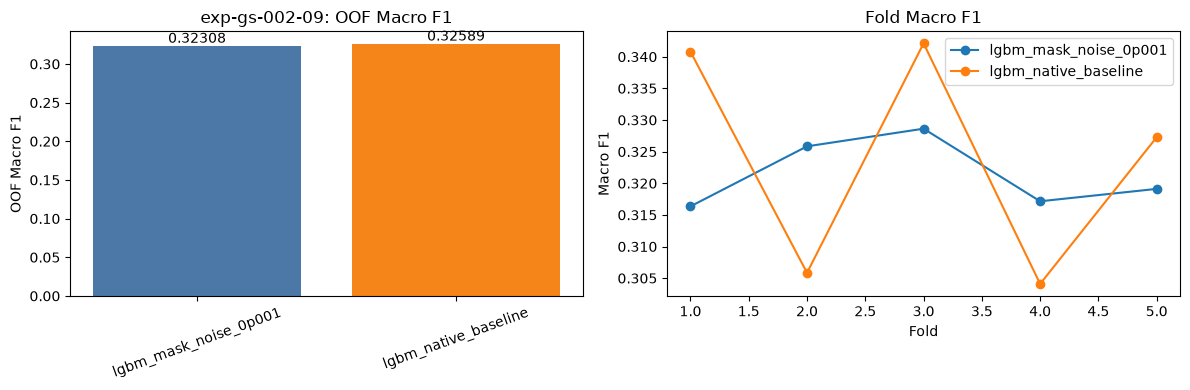

,candidate,model,cv_seed,oof_macro_f1,oof_accuracy,fold_macro_f1_mean,fold_macro_f1_std,feature_count,masked_train_cell_count,validation_masked_cell_count,runtime_seconds,delta_vs_baseline
0,lgbm_mask_noise_0p001,lightgbm,42,0.323078,0.338010,0.321415,0.004912,4384,108741,0,1089.143164,-0.00281
1,lgbm_native_baseline,lightgbm,42,0.325888,0.330753,0.324024,0.016411,4384,0,0,571.161574,0.00000


,candidate,class,precision,recall,class_f1,support
26,lgbm_mask_noise_0p001,ACC,0.870968,0.750000,0.805970,72.0
46,lgbm_mask_noise_0p001,SKCM,0.765690,0.663043,0.710680,276.0
30,lgbm_mask_noise_0p001,COAD,0.659193,0.659193,0.659193,223.0
49,lgbm_mask_noise_0p001,THCA,0.615385,0.617284,0.616333,324.0
51,lgbm_mask_noise_0p001,UCEC,0.606250,0.489899,0.541899,198.0
36,lgbm_mask_noise_0p001,LAML,0.554622,0.417722,0.476534,158.0
28,lgbm_mask_noise_0p001,BRCA,0.369088,0.555980,0.443655,786.0
31,lgbm_mask_noise_0p001,DLBC,0.588235,0.263158,0.363636,38.0
47,lgbm_mask_noise_0p001,STES,0.356941,0.332454,0.344262,379.0
32,lgbm_mask_noise_0p001,GBMLGG,0.308855,0.310195,0.309524,461.0


{'summary': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/eda_pre_002/result/exp-gs-002-09_summary.csv'), 'fold_scores': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/eda_pre_002/result/exp-gs-002-09_fold_scores.csv'), 'class_f1': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/eda_pre_002/result/exp-gs-002-09_class_f1.csv'), 'oof': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/eda_pre_002/result/exp-gs-002-09_oof.csv'), 'metadata': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/eda_pre_002/result/exp-gs-002-09_metadata.json'), 'plot': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/eda_pre_002/result/exp-gs-002-09_oof_macro_f1.png')}


In [5]:
if not runs:
    raise RuntimeError('RUN_EXPERIMENT=True으로 OOF 실행을 완료한 뒤 결과 셀을 실행하세요.')

summary_df = pd.DataFrame([item[0] for item in runs]).sort_values('candidate').reset_index(drop=True)
baseline_score = float(summary_df.loc[summary_df['candidate'].eq('lgbm_native_baseline'), 'oof_macro_f1'].iloc[0])
summary_df['delta_vs_baseline'] = summary_df['oof_macro_f1'] - baseline_score
fold_df = pd.concat([item[1] for item in runs], ignore_index=True)
class_f1_df = pd.concat([item[2] for item in runs], ignore_index=True)
oof_df = pd.concat([item[3].assign(candidate=item[0]['candidate']) for item in runs], ignore_index=True)

assert set(summary_df['candidate']) == {'lgbm_native_baseline', 'lgbm_mask_noise_0p001'}
assert int(fold_df['validation_masked_cell_count'].sum()) == 0
assert EVALUATION_DATA_READ is False

summary_path = RESULT_DIR / 'exp-gs-002-09_summary.csv'
fold_path = RESULT_DIR / 'exp-gs-002-09_fold_scores.csv'
class_path = RESULT_DIR / 'exp-gs-002-09_class_f1.csv'
oof_path = RESULT_DIR / 'exp-gs-002-09_oof.csv'
metadata_path = RESULT_DIR / 'exp-gs-002-09_metadata.json'
summary_df.to_csv(summary_path, index=False)
fold_df.to_csv(fold_path, index=False)
class_f1_df.to_csv(class_path, index=False)
oof_df.to_csv(oof_path, index=False)
metadata = {
    'experiment_id': 'exp-gs-002-09',
    'purpose': 'train-only missing-noise augmentation robustness comparison',
    'evaluation_data_read': EVALUATION_DATA_READ,
    'train_original_nan_count': train_nan_count,
    'mask_rate': MASK_RATE,
    'mask_seed': MASK_SEED,
    'mask_target_rule': 'uniform random cells in fold-train only',
    'validation_masked_cell_count': 0,
    'cv': {'n_splits': N_SPLITS, 'seed': CV_SEED},
    'lgbm_params': LGBM_PARAMS,
    'interpretation_limit': 'This evaluates clean-validation OOF after noisy training; it does not directly estimate missing-input performance.',
}
with metadata_path.open('w', encoding='utf-8') as file:
    json.dump(metadata, file, ensure_ascii=False, indent=2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(summary_df['candidate'], summary_df['oof_macro_f1'], color=['#4C78A8', '#F58518'])
axes[0].set_title('exp-gs-002-09: OOF Macro F1')
axes[0].set_ylabel('OOF Macro F1')
axes[0].tick_params(axis='x', rotation=20)
for row in summary_df.itertuples():
    axes[0].text(row.Index, row.oof_macro_f1, f'{row.oof_macro_f1:.5f}', ha='center', va='bottom')
for candidate, group in fold_df.groupby('candidate', sort=True):
    axes[1].plot(group['fold'], group['fold_macro_f1'], marker='o', label=candidate)
axes[1].set_title('Fold Macro F1')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('Macro F1')
axes[1].legend()
fig.tight_layout()
plot_path = RESULT_DIR / 'exp-gs-002-09_oof_macro_f1.png'
fig.savefig(plot_path, dpi=160, bbox_inches='tight')
plt.show()

display(summary_df)
display(class_f1_df.sort_values(['candidate', 'class_f1'], ascending=[True, False]).groupby('candidate').head(10))
print({'summary': summary_path, 'fold_scores': fold_path, 'class_f1': class_path, 'oof': oof_path, 'metadata': metadata_path, 'plot': plot_path})


## 판정 기준

- augmentation OOF Macro F1이 기준선보다 낮거나 동일하면 **기각/미검출**으로 종료한다.
- seed 42에서 개선되면 augmentation 후보만 `42 / 2024 / 777`로 다시 검증한다.
- 이 결과만으로 최종 제출 모델을 바꾸지 않으며, 3-seed 개선·실행 안정성 확인 뒤에만 별도 후보로 논의한다.
